# Road Surface Classification API Demonstration
This notebook demonstrates the functionality of D102 Helyx Machine Learning API.
The API allows you to:

✅ **Manage ML Models** (Upload, Enable, Disable, List)  
✅ **Perform Inference** (Classify road surfaces from images)  
✅ **Monitor Performance Metrics** (Inference time, Memory usage)  
✅ **Track Job History** (Previous API calls)  

**Base URL:** `http://localhost:8000`

# Upload a Model

In [1]:
from IPython.display import display, Markdown
import requests

display(Markdown("### **Upload a Model**"))
display(Markdown("Uploads a `.pth` model file to the archive and auto-detects the architecture."))

# Define model file path
model_path = "./models/enhanced_model.pth"  # Ensure you have a .pth model in the directory

# Upload Model
response = requests.post(
    "http://localhost:8000/models/upload",
    files={"uploaded_file": open(model_path, "rb")}
)

# Show Response
print(response.json())


### **Upload a Model**

Uploads a `.pth` model file to the archive and auto-detects the architecture.

{'message': "Model 'enhanced_model.pth' uploaded successfully.", 'architecture_detected': 'EnhancedCNN'}


# Disable a Model

In [2]:
display(Markdown("### **Disable a Model**"))
display(Markdown("Moves a model from active to the archive."))

# Disable the model
response = requests.post(f"http://localhost:8000/models/disable/{model_name}")

# Show Response
print(response.json())

### **Disable a Model**

Moves a model from active to the archive.

NameError: name 'model_name' is not defined

In [3]:
# 📌 Enable a Model
display(Markdown("### **Enable a Model**"))
display(Markdown("Moves a model from the archive to the active directory."))

model_name = "enhanced_model"  # Adjust to match the uploaded model

# Enable the model
response = requests.post(f"http://localhost:8000/models/enable/{model_name}")

# Show Response
print(response.json())

### **Enable a Model**

Moves a model from the archive to the active directory.

{'message': "Model 'enhanced_model' is now active."}


# List Active & Archived Models

In [4]:
display(Markdown("### **List Models**"))
display(Markdown("Lists models in both active and archived states."))

# List active models
response_active = requests.get("http://localhost:8000/models")
print("Active Models:", response_active.json())

# List archived models
response_archived = requests.get("http://localhost:8000/models/archived")
print("Archived Models:", response_archived.json())

### **List Models**

Lists models in both active and archived states.

Active Models: {'models': ['enhanced_model']}
Archived Models: {'archived_models': []}


# Get Model Metadata

In [5]:
display(Markdown("### **Get Model Metadata**"))
display(Markdown("Retrieves architecture, parameters, and file size of a model."))

# Get metadata of a specific model
response = requests.get(f"http://localhost:8000/models/metadata/{model_name}")
print(response.json())

### **Get Model Metadata**

Retrieves architecture, parameters, and file size of a model.

{'model_name': 'enhanced_model', 'architecture': 'EnhancedCNN', 'num_parameters': 23770947, 'file_size_mb': 90.99}


# Load a Model

In [6]:
display(Markdown("### **Load a Model**"))
display(Markdown("Loads a model into memory for inference."))

# Load a model into memory
response = requests.get(f"http://localhost:8000/models/load/{model_name}")
print(response.json())

### **Load a Model**

Loads a model into memory for inference.

{'message': "Model 'enhanced_model' loaded successfully"}


# Run Inference on All Images in test_images Folder


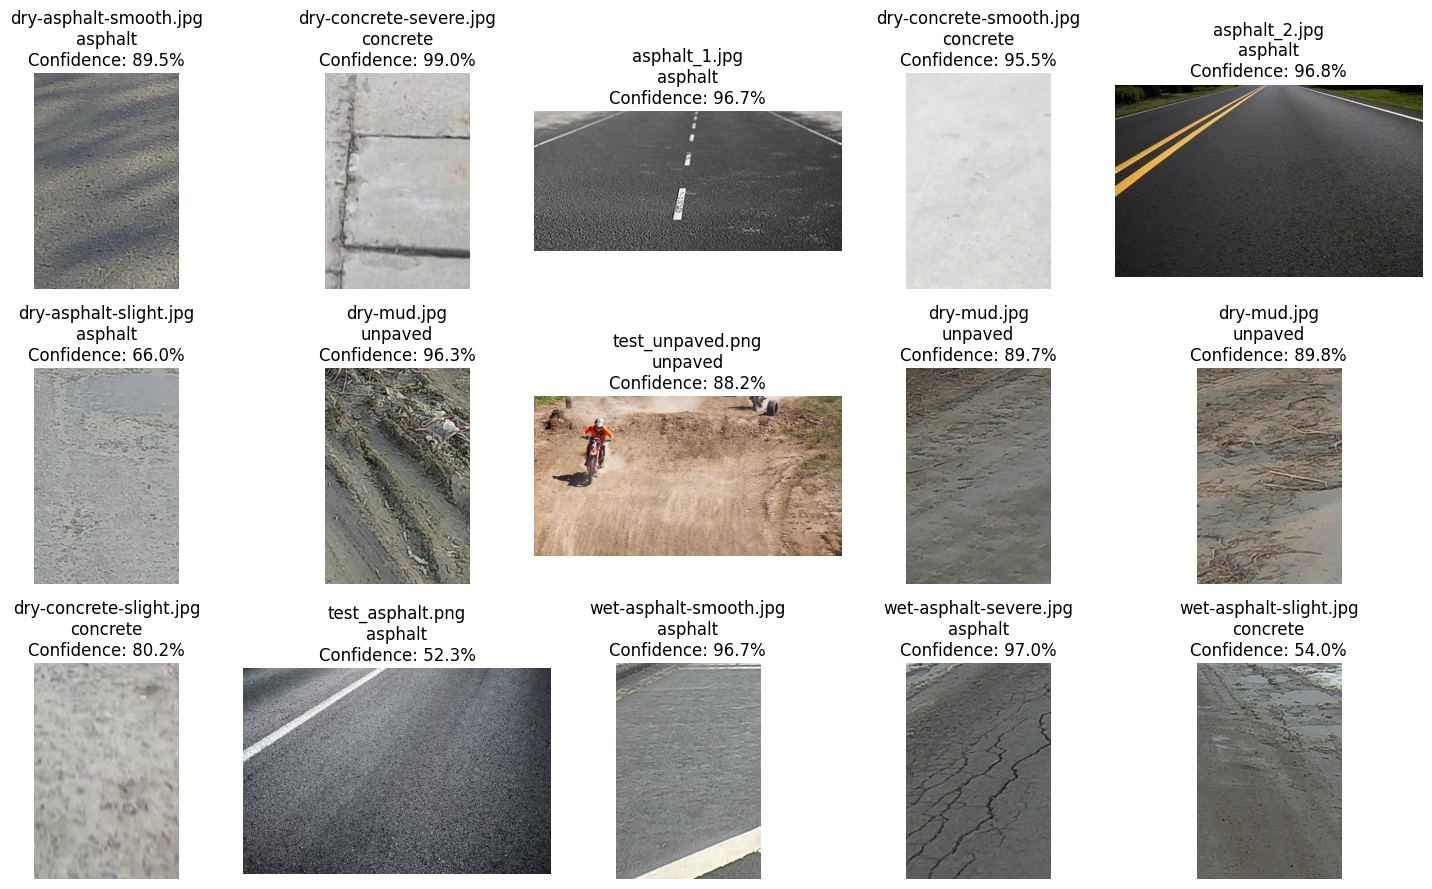

In [7]:
# 📌 Run Inference on All Images in test_images Folder
import requests
import os
import math
import matplotlib.pyplot as plt
from PIL import Image

# Define test images directory
test_images_dir = "./testing/test_images"

# Get all image files from the test_images directory
image_files = [f for f in os.listdir(test_images_dir) if f.endswith((".jpg", ".png"))]

# Define metadata JSON format
metadata_template = '{"data": [{"id": "%s"}]}'

# Limit 5 images per row
images_per_row = 5
num_rows = math.ceil(len(image_files) / images_per_row)

# Prepare a figure for displaying results
fig, axes = plt.subplots(num_rows, images_per_row, figsize=(15, num_rows * 3))

# Flatten axes array for easier iteration if multiple rows exist
axes = axes.flatten() if num_rows > 1 else [axes]

for i, image_file in enumerate(image_files):
    image_path = os.path.join(test_images_dir, image_file)

    # Extract meaningful part of the filename (after the first '-')
    formatted_filename = "-".join(image_file.split("-")[1:]) if "-" in image_file else image_file

    # Prepare metadata
    metadata_json = metadata_template % image_file

    # Send Inference Request
    response = requests.post(
        "http://localhost:8000/inference/execution",
        files={"image": open(image_path, "rb")},
        data={"json_string": metadata_json}
    )

    # Parse Response
    result = response.json()
    prediction = result["data"][0]["geoai_analysis"]["prediction"]
    confidence = result["data"][0]["geoai_analysis"]["confidence"]

    # Load and display the image
    img = Image.open(image_path)
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{formatted_filename}\n{prediction}\nConfidence: {confidence}")

# Hide any unused subplots (if images are not a perfect multiple of 5)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Show the plot
plt.tight_layout()
plt.show()


# Retrieve Performance Metrics

In [ ]:
display(Markdown("### **Retrieve Performance Metrics**"))
display(Markdown("Gets the last recorded inference time and memory usage."))

# Get Performance Metrics
response = requests.get("http://localhost:8000/performance")
print(response.json())

# Retrieve Job History

In [ ]:
import json
display(Markdown("### **Retrieve Job History**"))
display(Markdown("Lists all previous API calls."))

# Get Job History (All Requests)
response = requests.get("http://localhost:8000/jobs/history")
print(json.dumps(response.json(), indent=2))